# Games by decade

Header-only analysis — no PGN replay needed. Pure DuckDB SQL over the parquet shards.

Toggle `USE_FULL_CORPUS` to switch between the 100-game sample (default, instant) and the full ~900k-game corpus (still sub-second for this query).

In [1]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt

USE_FULL_CORPUS = False

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SHARD_DIR = ROOT / ("data/processed/games" if USE_FULL_CORPUS else "data/sample/games")
glob = str(SHARD_DIR / "*.parquet")
print(f"Reading shards from {SHARD_DIR}")

Reading shards from /Users/paul/pwsiegel/chess-move-stats/data/sample/games


Lumbra's `date` column is a string like `2024.07.15` or `2000.??.??`. We extract the year from the first 4 chars, dropping any rows where it isn't a valid integer (unknown dates are written `????`).

In [2]:
decades = duckdb.sql(f"""
    WITH parsed AS (
        SELECT TRY_CAST(SUBSTR(date, 1, 4) AS INTEGER) AS year
        FROM '{glob}'
    )
    SELECT year - (year % 10) AS decade,
           COUNT(*) AS games
    FROM parsed
    WHERE year IS NOT NULL
    GROUP BY decade
    ORDER BY decade
""").df()
decades

,decade,games
0,1970,6
1,1980,8
2,1990,17
3,2000,21
4,2010,24
5,2020,24


## Plot

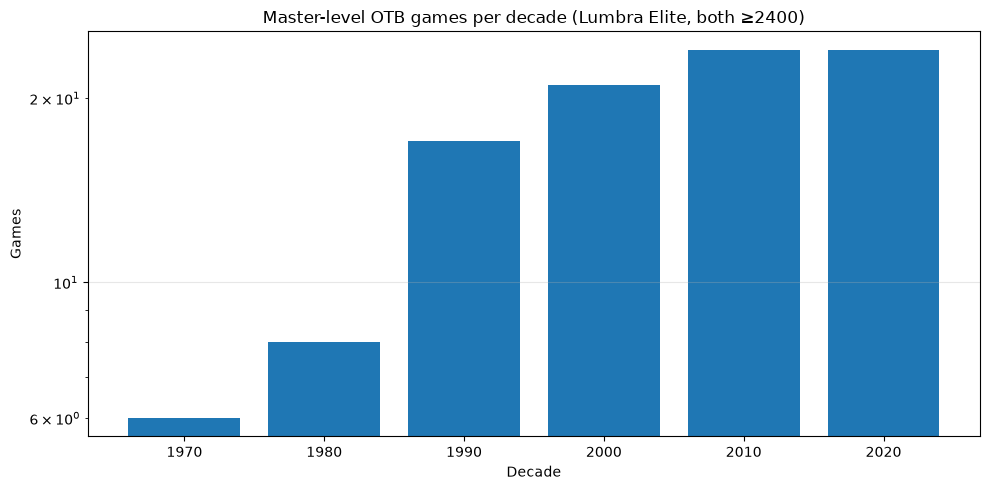

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(decades["decade"].astype(int), decades["games"], width=8)
ax.set_xlabel("Decade")
ax.set_ylabel("Games")
ax.set_title("Master-level OTB games per decade (Lumbra Elite, both ≥2400)")
ax.set_yscale("log")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()